## PUNTO 1 - Segmentación de comercios mediante Business Score

### Objetivo

Analizar el comportamiento de los comercios activos durante los
últimos seis meses para construir un modelo de segmentación
basado en reglas de negocio que permita orientar estrategias
de marketing y contribuir al incremento de las comisiones
generadas por la API de pagos.

#### Entradas

- Hoja: comercios
- Hoja: transacciones

#### Salidas

- Base consolidada
- Business Score
- Segmentos comerciales
- KPIs
- Datos para Dashboard

### *ETAPA 1 EDA (Análisis Exploratorio de Datos)*

#### Pregunta de negocio 1

¿Qué información tenemos disponible para resolver el problema?

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# 1. Configuración de visualización
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:,.2f}".format)
plt.style.use("ggplot")

In [53]:
# ==========================================================
# 2. Inspección del archivo Excel
# Objetivo:
# Identificar las hojas disponibles y validar la estructura
# del archivo suministrado por el cliente.
# ==========================================================

from pathlib import Path
import pandas as pd

archivo = Path("../data/raw/DataTransacciones_PruebasIngreso.xlsx")

excel = pd.ExcelFile(archivo)

print("Hojas encontradas:")
print(excel.sheet_names)

Hojas encontradas:
['comercios', 'transacciones']


In [6]:
# ==========================================================
# 3. Carga de datos
# Objetivo:
# Cargar las tablas de comercios y transacciones para iniciar
# el análisis exploratorio.
# ==========================================================

comercios = pd.read_excel(archivo, sheet_name="comercios")
transacciones = pd.read_excel(archivo, sheet_name="transacciones")

In [35]:
print("COMERCIOS")
display(comercios.head())

print("\nTRANSACCIONES")
display(transacciones.head())

COMERCIOS


,Id_comercio,Fecha vinculación datafono,Fecha de creacion comercio,Categoria comercio,Sub Categoria comercio,Id_terminal,Ciudad,Fecha 1ra_transaccion,Monto ventas Acumulado,Monto ventas ultimo mes
0,003QDVFJCJ,"mar. 26, 2021 12:40pm","mar. 26, 2021 12:17pm",Comercio detallista,Ropa / Accesorios,1299,Bogotá D.C.,"mar. 26, 2021 12:42pm",6542000,1240000
1,008LJH6YHN,"feb. 10, 2021 3:31pm","feb. 10, 2021 3:15pm",Belleza y cuidado personal,Spa,591,Bogotá D.C.,"feb. 10, 2021 3:34pm",4380000,1102000
2,00B3DGV62G,"mar. 3, 2021 3:26pm","mar. 3, 2021 3:09pm",Comercio detallista,Auto partes,2130,Bogotá D.C.,"mar. 3, 2021 3:30pm",11892500,1297000
3,00ILW1BB3Y,"mar. 24, 2021 12:45pm","mar. 24, 2021 12:33pm",Comercio detallista,Tienda naturista,662,Bogotá D.C.,"mar. 24, 2021 12:51pm",372500,74500
4,01AK7UX4UU,"mar. 30, 2021 1:50pm","mar. 30, 2021 1:40pm",Comercio detallista,Tecnología,1784,Mosquera,"mar. 30, 2021 1:52pm",165500,0



TRANSACCIONES


,Id_comercio,mes-anio transaccion,cantidad transacciones
0,003QDVFJCJ,2021-03-01,5
1,003QDVFJCJ,2021-04-01,9
2,003QDVFJCJ,2021-05-01,16
3,008LJH6YHN,2021-02-01,2
4,008LJH6YHN,2021-03-01,5


In [38]:
print("="*60)
print("COMERCIOS")
print("="*60)

display(comercios.info())

print("\n")

display(comercios.describe(include="all"))

print("\n"*2)

print("="*60)
print("TRANSACCIONES")
print("="*60)

display(transacciones.info())

print("\n")

display(transacciones.describe(include="all"))

COMERCIOS
<class 'pandas.DataFrame'>
RangeIndex: 3071 entries, 0 to 3070
Data columns (total 10 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   Id_comercio                 3071 non-null   str  
 1   Fecha vinculación datafono  3071 non-null   str  
 2   Fecha de creacion comercio  3071 non-null   str  
 3   Categoria comercio          3071 non-null   str  
 4   Sub Categoria comercio      3071 non-null   str  
 5   Id_terminal                 3071 non-null   int64
 6   Ciudad                      3071 non-null   str  
 7   Fecha 1ra_transaccion       3050 non-null   str  
 8   Monto ventas Acumulado      3071 non-null   int64
 9   Monto ventas ultimo mes     3071 non-null   int64
dtypes: int64(3), str(7)
memory usage: 240.1 KB


None

,Id_comercio,Fecha vinculación datafono,Fecha de creacion comercio,Categoria comercio,Sub Categoria comercio,Id_terminal,Ciudad,Fecha 1ra_transaccion,Monto ventas Acumulado,Monto ventas ultimo mes
count,3071,3071,3071,3071,3071,"3,071.00",3071,3050,"3,071.00","3,071.00"
unique,3015,2895,2838,8,71,NaN,64,2878,NaN,NaN
top,9WEPENSRWI,"mar. 23, 2021 1:07pm","ene. 21, 2021 4:20pm",Comercio detallista,Otro,NaN,Bogotá D.C.,"mar. 16, 2021 3:01pm",NaN,NaN
freq,5,3,5,1656,420,NaN,2476,10,NaN,NaN
mean,NaN,NaN,NaN,NaN,NaN,"1,542.89",NaN,NaN,"4,308,254.75","657,546.78"
std,NaN,NaN,NaN,NaN,NaN,888.93,NaN,NaN,"7,588,705.90","1,514,032.58"
min,NaN,NaN,NaN,NaN,NaN,1.00,NaN,NaN,0.00,0.00
25%,NaN,NaN,NaN,NaN,NaN,774.00,NaN,NaN,"307,000.00",0.00
50%,NaN,NaN,NaN,NaN,NaN,"1,543.00",NaN,NaN,"1,527,500.00","103,550.00"
75%,NaN,NaN,NaN,NaN,NaN,"2,312.50",NaN,NaN,"4,863,800.00","671,000.00"





TRANSACCIONES
<class 'pandas.DataFrame'>
RangeIndex: 8357 entries, 0 to 8356
Data columns (total 3 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   Id_comercio             8357 non-null   str           
 1   mes-anio transaccion    8357 non-null   datetime64[us]
 2   cantidad transacciones  8357 non-null   int64         
dtypes: datetime64[us](1), int64(1), str(1)
memory usage: 196.0 KB


None

,Id_comercio,mes-anio transaccion,cantidad transacciones
count,8357,8357,"8,357.00"
unique,3015,NaN,NaN
top,0UE0G86TAF,NaN,NaN
freq,6,NaN,NaN
mean,NaN,2021-03-16 09:48:16.111044,8.16
min,NaN,2020-12-01 00:00:00,1.00
25%,NaN,2021-03-01 00:00:00,2.00
50%,NaN,2021-04-01 00:00:00,4.00
75%,NaN,2021-04-01 00:00:00,9.00
max,NaN,2021-05-01 00:00:00,248.00


#### Pregunta de negocio 2

¿Los datos son confiables para realizar el análisis?

In [39]:
# ==========================================================
# 4. Calidad de los datos
# Objetivo:
# Validar que la información sea consistente antes de realizar
# el análisis y la segmentación.
# ==========================================================

print("COMERCIOS")
print("-"*50)

print(f"Registros: {len(comercios)}")
print(f"Comercios únicos: {comercios['Id_comercio'].nunique()}")

print()

print("TRANSACCIONES")
print("-"*50)

print(f"Registros: {len(transacciones)}")
print(f"Comercios únicos: {transacciones['Id_comercio'].nunique()}")

# Nulos
print("NULOS")
display(comercios.isnull().sum())

print()

display(transacciones.isnull().sum())

COMERCIOS
--------------------------------------------------
Registros: 3071
Comercios únicos: 3015

TRANSACCIONES
--------------------------------------------------
Registros: 8357
Comercios únicos: 3015
NULOS


Id_comercio                    0
Fecha vinculación datafono     0
Fecha de creacion comercio     0
Categoria comercio             0
Sub Categoria comercio         0
Id_terminal                    0
Ciudad                         0
Fecha 1ra_transaccion         21
Monto ventas Acumulado         0
Monto ventas ultimo mes        0
dtype: int64

Id_comercio               0
mes-anio transaccion      0
cantidad transacciones    0
dtype: int64

In [40]:
# ==========================================================
# 5. Revisión de posibles duplicados
# Objetivo:
# Entender por qué existen comercios repetidos antes de limpiar
# la información.
# ==========================================================

duplicados = comercios[
    comercios.duplicated(subset="Id_comercio", keep=False)
].sort_values("Id_comercio")

duplicados

,Id_comercio,Fecha vinculación datafono,Fecha de creacion comercio,Categoria comercio,Sub Categoria comercio,Id_terminal,Ciudad,Fecha 1ra_transaccion,Monto ventas Acumulado,Monto ventas ultimo mes
96,15VSQZS9OS,"feb. 5, 2021 8:40pm","feb. 5, 2021 8:30pm",Alimentos y bebidas,Comida rápida,744,Bogotá D.C.,"feb. 5, 2021 8:42pm",1862800,121800
97,15VSQZS9OS,"feb. 15, 2021 11:44am","feb. 5, 2021 8:30pm",Alimentos y bebidas,Comida rápida,730,Bogotá D.C.,"abr. 24, 2021 8:35pm",3271600,1012000
197,266OCTDJC5,"feb. 11, 2021 12:08pm","feb. 9, 2021 3:24pm",Servicios,Logística,832,Fusagasugá,"feb. 11, 2021 12:12pm",7210,0
198,266OCTDJC5,"feb. 25, 2021 11:00am","feb. 9, 2021 3:24pm",Servicios,Logística,1871,Fusagasugá,"feb. 25, 2021 11:04am",2000,0
311,3EICTQJZ66,"feb. 20, 2021 4:54pm","feb. 20, 2021 4:42pm",Comercio detallista,Ropa / Accesorios,1138,Soacha,"feb. 20, 2021 5:01pm",2000,0
...,...,...,...,...,...,...,...,...,...,...
2985,YVIJPP1A0G,"mar. 6, 2021 10:42am","ene. 5, 2021 4:19pm",Comercio detallista,Materiales de construcción,1254,Soacha,"mar. 9, 2021 2:32pm",3497256,0
3042,ZMJ7BCK0TN,"feb. 25, 2021 1:30pm","feb. 23, 2021 4:41pm",Comercio detallista,Elementos de seguridad,2738,Bogotá D.C.,NaN,0,0
3043,ZMJ7BCK0TN,"feb. 23, 2021 4:50pm","feb. 23, 2021 4:41pm",Comercio detallista,Elementos de seguridad,2726,Bogotá D.C.,"feb. 23, 2021 4:52pm",2000,0
3047,ZNN47AMZMD,"feb. 22, 2021 12:57pm","feb. 22, 2021 12:51pm",Comercio detallista,Óptica,1145,Bogotá D.C.,"feb. 22, 2021 1:01pm",2000,0


##### **Hallazgo 1**

Se identificaron **3071 registros** en la tabla de comercios, pero únicamente **3015 comercios únicos**.

Esto indica la existencia de registros repetidos que deben ser analizados antes de cualquier proceso de segmentación.

En esta etapa no se eliminan registros automáticamente, ya que primero es necesario comprender el origen de la duplicidad para evitar pérdida de información.

In [41]:
# ==========================================================
# 6. ¿Los registros repetidos corresponden a varios terminales?
# ==========================================================

duplicados.groupby("Id_comercio").agg(
    registros=("Id_comercio","count"),
    terminales=("Id_terminal","nunique")
).head(10)

,registros,terminales
Id_comercio,,
15VSQZS9OS,2,2
266OCTDJC5,2,2
3EICTQJZ66,2,2
4AX7GUYCLI,2,2
4NW1JZ9BSG,2,2
5KI7RGY0WW,2,2
5T9TR5NGI0,2,2
6PDAJ0HTJK,2,2
89F1XUB63U,2,2


In [17]:
duplicados.groupby("Id_comercio")["Id_terminal"].nunique().value_counts()

Id_terminal
2    42
3     5
5     1
Name: count, dtype: int64

In [42]:
# ==========================================
# Validación de registros adicionales
# ==========================================

conteo = comercios["Id_comercio"].value_counts()

registros_extra = (conteo - 1).sum()

print(f"Registros adicionales: {registros_extra}")
print(f"Diferencia esperada: {len(comercios) - comercios['Id_comercio'].nunique()}")

Registros adicionales: 56
Diferencia esperada: 56


##### **Hallazgo 2**

Durante la validación inicial se observó que la tabla Comercios contiene 3.071 registros, pero únicamente 3.015 identificadores de comercio únicos. Esto genera una diferencia de 56 registros adicionales, lo que inicialmente podría interpretarse como duplicados.

Sin embargo, al analizar el campo Id_terminal se evidenció que estos registros corresponden a comercios que operan con múltiples terminales y no a errores de calidad de los datos.

En total se identificaron:

42 comercios con 2 terminales.
5 comercios con 3 terminales.
1 comercio con 5 terminales.

Estos casos representan exactamente los 56 registros adicionales detectados durante la validación inicial:

(42×1)+(5×2)+(1×4)=56

Es decir, cada terminal adicional genera un registro adicional para el mismo comercio.

Decisión tomada

No se eliminarán estos registros durante la etapa de calidad de datos, ya que representan información válida del negocio. Más adelante, durante la construcción del modelo de segmentación, la información será consolidada a nivel de Id_comercio, de forma que cada cliente quede representado una única vez, agregando correctamente la información proveniente de todos sus terminales.

#### Pregunta de negocio 3

¿Cuál es el período disponible en la información y cuáles son los seis meses que serán utilizados para el análisis?

In [43]:
# ==========================================================
# 7. Período disponible
# ==========================================================

transacciones["mes-anio transaccion"] = pd.to_datetime(
    transacciones["mes-anio transaccion"],
    format="%m-%Y"
)

print("Fecha mínima:", transacciones["mes-anio transaccion"].min())
print("Fecha máxima:", transacciones["mes-anio transaccion"].max())

print("\nMeses disponibles:")

display(
    transacciones["mes-anio transaccion"]
    .drop_duplicates()
    .sort_values()
)

Fecha mínima: 2020-12-01 00:00:00
Fecha máxima: 2021-05-01 00:00:00

Meses disponibles:


15   2020-12-01
56   2021-01-01
3    2021-02-01
0    2021-03-01
1    2021-04-01
2    2021-05-01
Name: mes-anio transaccion, dtype: datetime64[us]

##### **Hallazgo 3**

La información transaccional disponible comprende un período de seis meses, desde diciembre de 2020 hasta mayo de 2021.

Fecha mínima	Fecha máxima
Diciembre 2020	Mayo 2021

Este período coincide exactamente con el alcance solicitado ("últimos seis meses"), por lo que todo el histórico disponible será utilizado para el análisis y la segmentación.

No será necesario realizar filtros adicionales por fecha.

#### Pregunta de negocio 4

¿Cómo se distribuye la actividad transaccional de los comercios?

*Antes de definir un modelo de segmentación es necesario comprender el comportamiento de las transacciones realizadas por los comercios.*

*En esta etapa se analizará la distribución de la cantidad de transacciones registradas durante el período disponible con el fin de identificar el comportamiento típico de los comercios, detectar posibles valores atípicos y entender si existe una concentración de la actividad en un pequeño grupo de clientes.*

*Este análisis permitirá fundamentar las decisiones posteriores relacionadas con la segmentación y la priorización comercial.*

In [44]:
# ==========================================
# 8. Consolidar transacciones por comercio
# ==========================================

transacciones_comercio = (
    transacciones
    .groupby("Id_comercio", as_index=False)
    .agg(
        total_transacciones=("cantidad transacciones", "sum"),
        promedio_mensual=("cantidad transacciones", "mean"),
        meses_con_transacciones=("mes-anio transaccion", "count")
    )
)

display(transacciones_comercio.head())

,Id_comercio,total_transacciones,promedio_mensual,meses_con_transacciones
0,003QDVFJCJ,30,10.00,3
1,008LJH6YHN,10,2.50,4
2,00B3DGV62G,65,21.67,3
3,00ILW1BB3Y,8,2.67,3
4,01AK7UX4UU,4,2.00,2


In [45]:
# ==========================================
# 9. Distribución de las transacciones
# ==========================================

transacciones_comercio["total_transacciones"].describe(
    percentiles=[0.25,0.50,0.75,0.90,0.95,0.99]
)

count   3,015.00
mean       22.60
std        43.20
min         1.00
25%         3.00
50%        10.00
75%        23.00
90%        53.00
95%        86.00
99%       191.44
max       740.00
Name: total_transacciones, dtype: float64

In [46]:
print(f"Media: {transacciones_comercio['total_transacciones'].mean():.2f}")

print(f"Mediana: {transacciones_comercio['total_transacciones'].median():.2f}")

print(f"Desviación estándar: {transacciones_comercio['total_transacciones'].std():.2f}")

Media: 22.60
Mediana: 10.00
Desviación estándar: 43.20


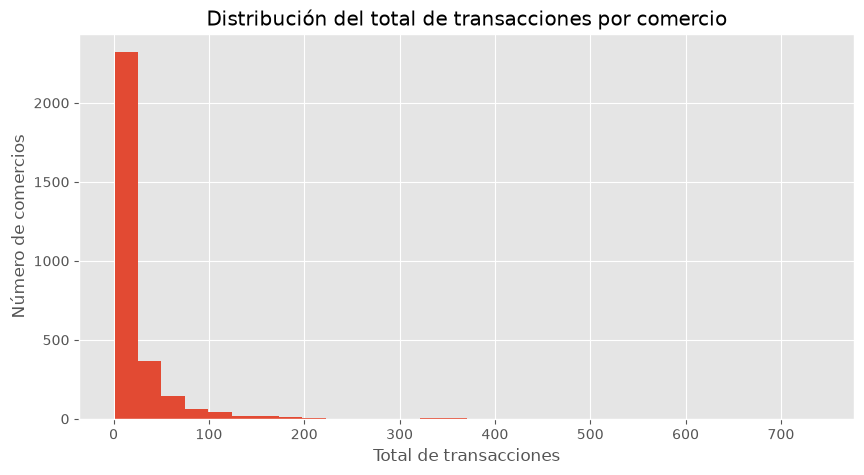

In [47]:
# ==========================================
# 10. Distribución de transacciones
# ==========================================

plt.figure(figsize=(10,5))

plt.hist(
    transacciones_comercio["total_transacciones"],
    bins=30
)

plt.title("Distribución del total de transacciones por comercio")
plt.xlabel("Total de transacciones")
plt.ylabel("Número de comercios")

plt.show()

##### **Hallazgo 4**

La actividad transaccional presenta una distribución altamente asimétrica. La mayoría de los comercios registra un bajo volumen de transacciones, mientras que un grupo reducido concentra una actividad considerablemente mayor. Esta diferencia se evidencia en los percentiles, la dispersión observada y la presencia de valores atípicos.

Estos resultados indican que la frecuencia de transacciones posee un alto poder discriminante para diferenciar el desempeño de los comercios, por lo que será analizada en detalle durante la construcción del Business Score.

#### Pregunta de negocio 5

¿Qué categorías concentran la mayor actividad?

In [48]:
categoria_transacciones = (
    comercios
    .merge(transacciones_comercio, on="Id_comercio", how="left")
    .groupby("Categoria comercio")
    .agg(
        comercios=("Id_comercio","nunique"),
        transacciones=("total_transacciones","sum")
    )
    .sort_values("transacciones", ascending=False)
)

categoria_transacciones

,comercios,transacciones
Categoria comercio,,
Comercio detallista,1625,32967
Alimentos y bebidas,382,20390
Servicios,514,9574
Belleza y cuidado personal,206,4693
Reparación y limpieza,167,2408
Turismo y entretenimiento,35,922
Transporte,76,600
Educación,10,68


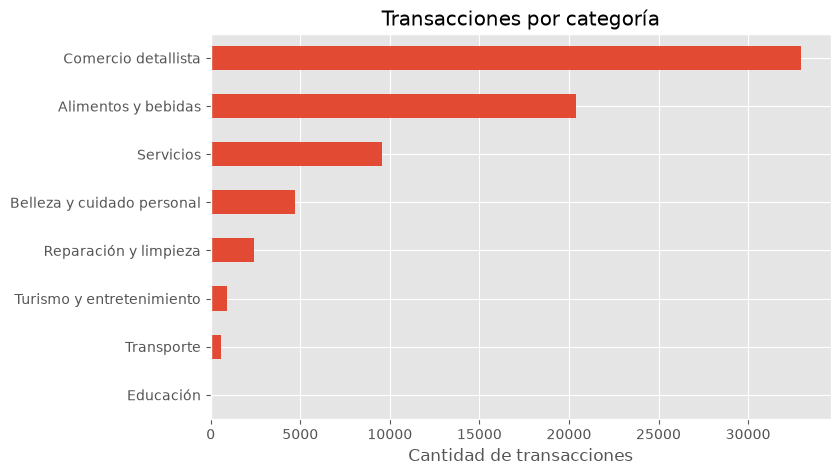

In [49]:
# ==========================================
# 11. Transacciones por categoría
# ==========================================

categoria_transacciones.sort_values("transacciones").plot(
    kind="barh",
    y="transacciones",
    figsize=(8,5),
    legend=False
)

plt.title("Transacciones por categoría")
plt.xlabel("Cantidad de transacciones")
plt.ylabel("")
plt.show()

##### **Hallazgo 5**

La actividad transaccional se concentra principalmente en dos categorías:

- Comercio detallista.
- Alimentos y bebidas.

Estas categorías representan la mayor parte de las transacciones registradas durante el período analizado, lo que sugiere que cualquier estrategia comercial orientada a incrementar el uso de la API debería priorizar estos segmentos por su mayor potencial de generación de comisiones.

No obstante, la segmentación posterior se realizará a nivel de comercio y no por categoría, ya que el objetivo es identificar el desempeño individual de cada cliente.

#### Pregunta de negocio 6

¿Dónde está concentrado el negocio?

In [50]:
ciudad_transacciones = (
    comercios
    .merge(transacciones_comercio, on="Id_comercio", how="left")
    .groupby("Ciudad")
    .agg(
        comercios=("Id_comercio","nunique"),
        transacciones=("total_transacciones","sum")
    )
    .sort_values("transacciones", ascending=False)
)

ciudad_transacciones.head(10)

,comercios,transacciones
Ciudad,,
Bogotá D.C.,2431,58004
Soacha,176,5938
Cali,107,1483
Choachí,18,572
Melgar,6,527
Chía,31,522
Fusagasugá,37,480
Cota,14,335
Mosquera,9,335


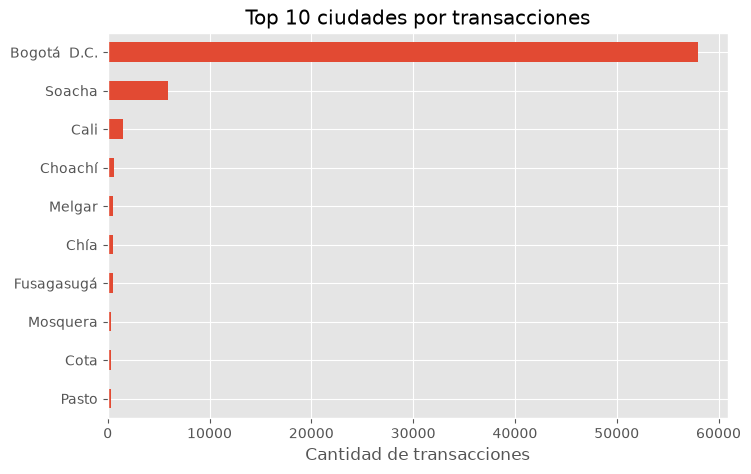

In [51]:
# ==========================================
# 12. Top ciudades
# ==========================================

ciudad_transacciones.head(10).sort_values("transacciones").plot(
    kind="barh",
    y="transacciones",
    figsize=(8,5),
    legend=False
)

plt.title("Top 10 ciudades por transacciones")
plt.xlabel("Cantidad de transacciones")
plt.ylabel("")
plt.show()

##### **Hallazgo 6**

Bogotá concentra la mayor parte de los comercios y del volumen transaccional del negocio.

Este resultado evidencia una fuerte concentración geográfica de la operación, aspecto que deberá considerarse al momento de diseñar campañas de marketing, ya que las estrategias nacionales podrían complementarse con acciones específicas para las ciudades con mayor actividad.

#### Pregunta de negocio 7

¿Cómo evoluciona el volumen de transacciones durante el período analizado?

In [52]:
# ==========================================
# 13. Evolución mensual
# ==========================================

evolucion = (
    transacciones
    .groupby("mes-anio transaccion")["cantidad transacciones"]
    .sum()
    .reset_index()
)

evolucion

,mes-anio transaccion,cantidad transacciones
0,2020-12-01,1408
1,2021-01-01,2234
2,2021-02-01,6134
3,2021-03-01,18205
4,2021-04-01,17222
5,2021-05-01,22949


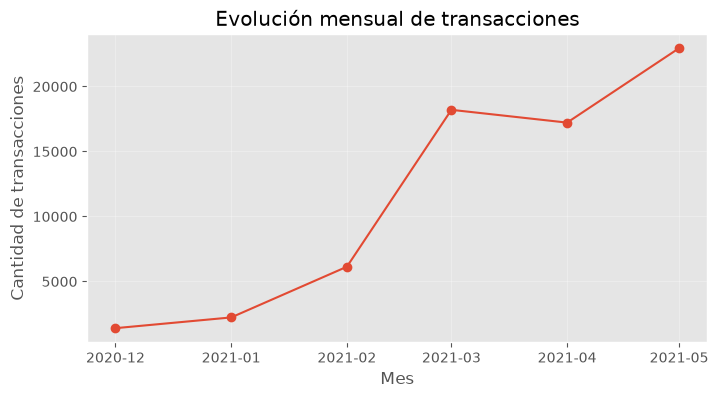

In [32]:
plt.figure(figsize=(8,4))

plt.plot(
    evolucion["mes-anio transaccion"],
    evolucion["cantidad transacciones"],
    marker="o"
)

plt.title("Evolución mensual de transacciones")
plt.xlabel("Mes")
plt.ylabel("Cantidad de transacciones")

plt.grid(alpha=0.3)

plt.show()

##### **Hallazgo 7**

Durante los seis meses analizados se observa una tendencia creciente en el número de transacciones procesadas por la plataforma.

Aunque existe una ligera disminución entre marzo y abril, el comportamiento general es de crecimiento, alcanzando el mayor volumen de transacciones en mayo de 2021.

Este resultado respalda la inclusión de una variable de tendencia dentro del Business Score, ya que no solo interesa identificar los comercios con mayor actividad, sino también aquellos cuyo comportamiento evidencia un crecimiento sostenido y, por tanto, un mayor potencial para incrementar las comisiones generadas por la API.